In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

data_dir = 'dataset/'

# Set plot styles for better visuals
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# 1. Data Overview and Structure

# Setting up description mechanism
description = pd.read_csv(os.path.join(data_dir, 'WiDS_Datathon_2020_Dictionary.csv'))
description_dict = description.set_index('Variable Name').to_dict(orient='index')

# Reading data
df = pd.read_csv(os.path.join(data_dir, 'training_v2.csv'))

In [3]:
df

,encounter_id,patient_id,hospital_id,hospital_death,age,bmi,elective_surgery,ethnicity,gender,height,...,aids,cirrhosis,diabetes_mellitus,hepatic_failure,immunosuppression,leukemia,lymphoma,solid_tumor_with_metastasis,apache_3j_bodysystem,apache_2_bodysystem
0,66154,25312,118,0,68.0,22.730000,0,Caucasian,M,180.3,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
1,114252,59342,81,0,77.0,27.420000,0,Caucasian,F,160.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory
2,119783,50777,118,0,25.0,31.950000,0,Caucasian,F,172.7,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
3,79267,46918,118,0,81.0,22.640000,1,Caucasian,F,165.1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Cardiovascular,Cardiovascular
4,92056,34377,33,0,19.0,NaN,0,Caucasian,M,188.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Trauma,Trauma
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91708,91592,78108,30,0,75.0,23.060250,0,Caucasian,M,177.8,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,Sepsis,Cardiovascular
91709,66119,13486,121,0,56.0,47.179671,0,Caucasian,F,183.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Sepsis,Cardiovascular
91710,8981,58179,195,0,48.0,27.236914,0,Caucasian,M,170.2,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,Metabolic,Metabolic
91711,33776,120598,66,0,NaN,23.297481,0,Caucasian,F,154.9,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Respiratory,Respiratory


In [4]:
# Print the shape and first few rows to get an idea of the data dimensions and content.
print("Number of samples\t:", df.shape[0])
print("Number of features\t:", df.shape[1])

Number of samples	: 91713
Number of features	: 186


In [6]:
# Import necessary libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import IterativeImputer


In [7]:
# Reload the original dataset
df_original = pd.read_csv(os.path.join(data_dir, 'training_v2.csv'))

# Split into features and target
X = df_original.drop(columns=['hospital_death'])
y = df_original['hospital_death']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Print dataset information
print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")
print(f"Mortality rate in training set: {y_train.mean():.2%}")
print(f"Mortality rate in testing set: {y_test.mean():.2%}")


Training set size: (73370, 185)
Testing set size: (18343, 185)
Mortality rate in training set: 8.63%
Mortality rate in testing set: 8.63%


In [8]:
# Function to create different preprocessing pipelines
def create_preprocessing_pipeline(imputation_strategy='simple'):
    """
    Create a preprocessing pipeline with different imputation strategies
    
    Parameters:
    -----------
    imputation_strategy : str
        'simple': Use SimpleImputer with mean for numerical, most frequent for categorical
        'knn': Use KNNImputer for numerical features
        'iterative': Use IterativeImputer (MICE) for numerical features
        
    Returns:
    --------
    preprocessor : ColumnTransformer
    """
    # Numerical preprocessing
    if imputation_strategy == 'simple':
        numerical_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='mean')),
            ('scaler', StandardScaler())
        ])
    elif imputation_strategy == 'knn':
        numerical_transformer = Pipeline(steps=[
            ('imputer', KNNImputer(n_neighbors=5)),
            ('scaler', StandardScaler())
        ])
    elif imputation_strategy == 'iterative':
        numerical_transformer = Pipeline(steps=[
            ('imputer', IterativeImputer(max_iter=10, random_state=42)),
            ('scaler', StandardScaler())
        ])
    
    # Categorical preprocessing is the same for all strategies
    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Combine transformers in a column transformer
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numerical_transformer, numerical_cols),
            ('cat', categorical_transformer, categorical_cols)
        ],
        remainder='drop'  # Drop columns not specified in the transformers
    )
    
    return preprocessor


In [9]:
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

Classification Report - Simple Imputation:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92     16760
           1       0.35      0.69      0.46      1583

    accuracy                           0.86     18343
   macro avg       0.66      0.78      0.69     18343
weighted avg       0.91      0.86      0.88     18343



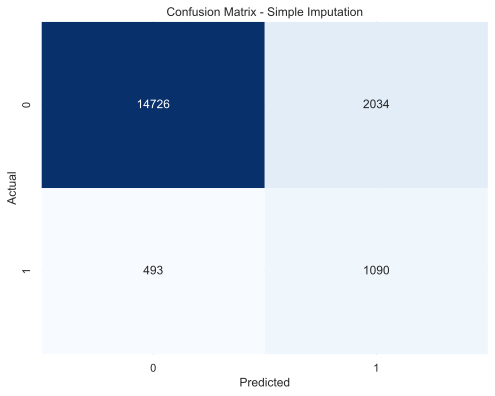

In [10]:
# Create and fit a pipeline with simple imputation
simple_preprocessor = create_preprocessing_pipeline('simple')

# Create a pipeline with preprocessing and random forest
pipe_rf_simple = Pipeline(steps=[
    ('preprocessor', simple_preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100, 
        max_depth=10,
        min_samples_split=10,
        random_state=42,
        class_weight='balanced',
        n_jobs=-1
    ))
])

# Fit the pipeline to the training data
pipe_rf_simple.fit(X_train, y_train)

# Evaluate on the test set
y_pred_simple = pipe_rf_simple.predict(X_test)
y_proba_simple = pipe_rf_simple.predict_proba(X_test)[:, 1]

# Print classification report
print("Classification Report - Simple Imputation:")
print(classification_report(y_test, y_pred_simple))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_simple)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix - Simple Imputation')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()



## Fairness-Aware training

In [11]:
print(df['ethnicity'].value_counts())

ethnicity
Caucasian           70684
African American     9547
Other/Unknown        4374
Hispanic             3796
Asian                1129
Native American       788
Name: count, dtype: int64


In [12]:
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference

sensitive_features = X_test['ethnicity'].astype(str).replace('nan', 'Missing')  

demographic_parity = demographic_parity_difference(y_test, y_pred_simple, sensitive_features=sensitive_features)
equalized_odds = equalized_odds_difference(y_test, y_pred_simple, sensitive_features=sensitive_features)

print("Demographic Parity Difference:", demographic_parity)
print("Equalized Odds Difference:", equalized_odds)

Demographic Parity Difference: 0.08257268424611225
Equalized Odds Difference: 0.29004329004329


- DPD: Measures the difference in selection rates (i.e., predicted positive rates) across different groups. Ideal value 0, meaning predictions are independent of ethnicity. (Now it's 8.257)
- EOD: Measures the worst-case disparity in true positive rates (TPR) and false positive rates (FPR) between groups. Again, ideal value 0. (Now it's 29%)

In [13]:
import numpy as np
import pandas as pd
from fairlearn.preprocessing import CorrelationRemover
from fairlearn.reductions import GridSearch, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import accuracy_score, balanced_accuracy_score

In [14]:
ethnicity_index = X_train.columns.get_loc("ethnicity")

In [15]:
# 1. PRE-PROCESSING 

sensitive_attr = X_train['ethnicity'].astype(str).replace('nan', 'Missing')  

# Handle class imbalance using sample weighting
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train) # Replace with SMOTE ( i guess Kevin is doing that)

X_train_pre = simple_preprocessor.fit_transform(X_train)
X_test_pre = simple_preprocessor.fit_transform(X_test)

# Remove correlations with ethnicity
corr_remover = CorrelationRemover(sensitive_feature_ids=[ethnicity_index]) 
X_train_transformed = corr_remover.fit_transform(X_train_pre)
X_test_transformed = corr_remover.transform(X_test_pre)

In-precessing techniques for fairness-aware optimization are GridSearch or ExponentiatedGradient, both of which are complex for non-linear models like Random Forest. It may be better to use Logistic Regression. 

In [17]:
# 2. IN-PROCESSING 
base_model = RandomForestClassifier(n_estimators=10, random_state=42, class_weight="balanced")

mitigator = GridSearch(base_model, constraints=DemographicParity(), grid_size=5)
mitigator.fit(X_train_transformed, y_train, sensitive_features=sensitive_attr)

y_pred_fair = mitigator.predict(X_test_transformed)

print("Accuracy (Fair Random Forest Model):", accuracy_score(y_test, y_pred_fair))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_fair))

The grid has 6 dimensions. It is not recommended to use more than 4, otherwise a prohibitively large grid size is required to explore the space thoroughly. For such cases consider using ExponentiatedGradient from the fairlearn.reductions module.
Generating a grid with 5 grid points. It is recommended to use at least 64 grid points. Please consider increasing grid_size.


Accuracy (Fair Random Forest Model): 0.9168075014992095
Balanced Accuracy: 0.5340210801821863


In [18]:
#  3. POST-PROCESSING 
postprocessor = ThresholdOptimizer(
    estimator=mitigator, constraints="demographic_parity", prefit=True
)
postprocessor.fit(X_train_transformed, y_train, sensitive_features=sensitive_attr)

sensitive_attr = X_test['ethnicity'].astype(str).replace('nan', 'Missing') 
y_pred_postprocessed = postprocessor.predict(X_test_transformed, sensitive_features=sensitive_attr)

print("Accuracy (Post-Processed Fair Model):", accuracy_score(y_test, y_pred_postprocessed))
print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_postprocessed))

Accuracy (Post-Processed Fair Model): 0.8958185683912119
Balanced Accuracy: 0.5614345326311632


Balanced accuracy has improved from before.

## Explainability

PermutationExplainer explainer: 501it [02:27,  3.16it/s]                         
C:\Users\rames\AppData\Local\Temp\ipykernel_11508\1454218503.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test_sample)


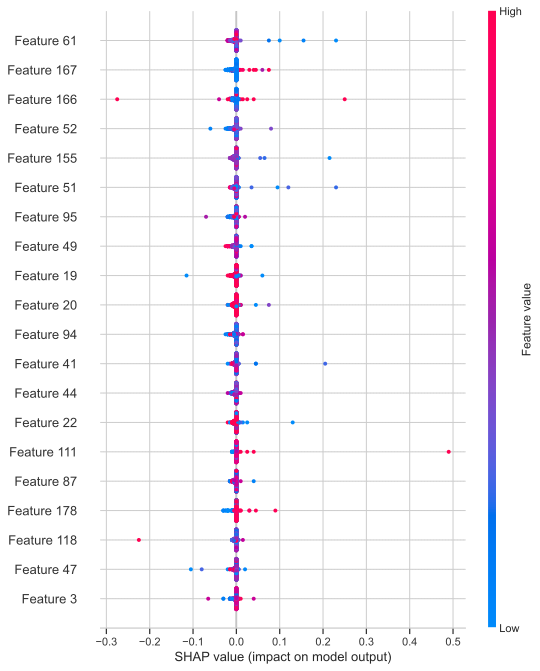

In [ ]:
import shap

# Full test set takes about 1.5 hours
X_test_sample = X_test_transformed[:500]

explainer = shap.Explainer(mitigator.predict, X_train_transformed)
shap_values = explainer(X_test_sample)

# GLOBAL EXPLANATION (Feature Importance)
shap.summary_plot(shap_values, X_test_sample)

In [ ]:
# Some error

from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    X_train.values, 
    feature_names=X_train.columns, 
    class_names=[0, 1],
    mode="classification"
)

# LOCAL EXPLANATION (single prediction)
sample_index = 10
exp = explainer.explain_instance(X_test_transformed.iloc[sample_index].values, mitigator.predict_proba)
exp.show_in_notebook()


Both Shap and LIME is not computationally efficient. For large datasets like this, interpretML is the best.

In [ ]:
# Takes approximately 10 minutes

from interpret.glassbox import ExplainableBoostingClassifier
from interpret import show

ebm = ExplainableBoostingClassifier()
ebm.fit(X_train_transformed, y_train)

ebm_global = ebm.explain_global()
show(ebm_global)

<!-- http://127.0.0.1:7001/2476653574960/ -->